# Layer 5 — Difference Analysis

Extracts per-joint angle deviations from DTW-aligned frame pairs and ranks the worst offenders per movement.

**Workflow**
1. Load master + student poses and extract per-frame angles
2. Segment both sequences into movement boundaries
3. DTW-align all 19 movements
4. Load per-joint thresholds from `master_data/chon_ji/thresholds.json`
5. Run `summarize_movement_issues()` — print issue tables for movements 1–3
6. Overview bar chart — worst issue severity per movement

In [1]:
# ── CONFIG ────────────────────────────────────────────────────────────────────
POOMSAE           = "chon_ji"    # folder name under master_data/ and sample_videos/
STUDENT_NAME      = "student"    # filename (without extension) inside sample_videos/{POOMSAE}/
STUDENT_END_FRAME   = 1160       # last frame of poomsae content
MASTER_START_FRAME  = 0          # first frame of actual master poomsae (after ready stance)
STUDENT_START_FRAME = 0          # first frame of actual student poomsae (after ready stance)
TOP_N               = 3          # worst joints to report per movement
SHOW_MOVEMENTS    = [1, 2, 3]    # movements to print in detail
# ──────────────────────────────────────────────────────────────────────────────

In [2]:
import os
import pathlib
import sys
import warnings

import matplotlib.pyplot as plt
import numpy as np

project_root = pathlib.Path(os.getcwd()).parent.parent
sys.path.insert(0, str(project_root))

from itf_analysis.normalization.normalizer import normalize_pose, extract_joint_angles
from itf_analysis.segmentation.keypose_matcher import load_master_keyposes
from itf_analysis.segmentation.segmentor import load_poses_from_json
from itf_analysis.segmentation.segmenter import segment_movements
from itf_analysis.alignment.dtw_aligner import (
    build_movement_segments, align_all_movements
)
from itf_analysis.feedback.difference_analyzer import (
    load_thresholds, summarize_movement_issues
)

sample_dir      = project_root / "itf_analysis" / "sample_videos"
poomsae_dir     = sample_dir / POOMSAE
master_dir      = project_root / "itf_analysis" / "master_data" / POOMSAE
keyposes_path   = str(master_dir / "keyposes_angles.json")
thresholds_path = str(master_dir / "thresholds.json")

MASTER_POSES_PATH  = str(poomsae_dir / "master_poses.json")
STUDENT_POSES_PATH = str(poomsae_dir / f"{STUDENT_NAME}_poses.json")

print("Imports OK")

Imports OK


## Step 1 — Load master angles + boundaries

In [3]:
master_frames = load_poses_from_json(MASTER_POSES_PATH)
master_fps = 1000.0 / (master_frames[1].timestamp_ms - master_frames[0].timestamp_ms)

master_angles = []
for f in master_frames:
    norm = normalize_pose(f.landmarks)
    if norm is not None:
        master_angles.append((f.frame_index, extract_joint_angles(norm)))

keyposes = load_master_keyposes(keyposes_path)

with warnings.catch_warnings(record=True):
    warnings.simplefilter("always")
    master_boundaries = segment_movements(master_angles, keyposes, master_fps, start_frame=MASTER_START_FRAME)

master_segments = build_movement_segments(master_angles, master_boundaries)
print(f"Master: {len(master_angles)} frames  |  {len(master_boundaries)} boundaries  |  {len(master_segments)} segments")

Master: 1151 frames  |  19 boundaries  |  19 segments


## Step 2 — Load student angles + boundaries

In [4]:
student_frames = load_poses_from_json(STUDENT_POSES_PATH)
student_fps = 1000.0 / (student_frames[1].timestamp_ms - student_frames[0].timestamp_ms)

student_angles = []
for f in student_frames:
    norm = normalize_pose(f.landmarks)
    if norm is not None:
        student_angles.append((f.frame_index, extract_joint_angles(norm)))

keyposes_no_src = [{k: v for k, v in kp.items() if k != "source_frame"} for kp in keyposes]

with warnings.catch_warnings(record=True):
    warnings.simplefilter("always")
    student_boundaries = segment_movements(
        student_angles, keyposes_no_src, student_fps,
        start_frame=STUDENT_START_FRAME, end_frame=STUDENT_END_FRAME
    )

student_segments = build_movement_segments(student_angles, student_boundaries)

from collections import Counter
conf = Counter(b.confidence for b in student_boundaries)
print(f"Student: {len(student_angles)} frames  |  {len(student_boundaries)} boundaries")
print(f"  Confidence: high={conf['high']}  medium={conf['medium']}  low={conf['low']}")

Student: 1219 frames  |  19 boundaries
  Confidence: high=2  medium=17  low=0


## Step 3 — DTW-align all movements

In [5]:
all_results = align_all_movements(master_segments, student_segments)
print(f"Aligned {len(all_results)} / 19 movements")

Aligned 19 / 19 movements


## Step 4 — Load thresholds

In [6]:
thresholds = load_thresholds(thresholds_path)
print(f"Poomsae  : {thresholds['poomsae']}")
print(f"Version  : {thresholds['schema_version']}")
print("Defaults :")
for joint, thr in thresholds["defaults"].items():
    overrides = [
        str(mov) for mov, ov in thresholds["movements"].items()
        if joint in ov
    ]
    override_note = f"  (overridden in movs {', '.join(overrides)})" if overrides else ""
    print(f"  {joint:25s}: {thr}°{override_note}")

Poomsae  : chon_ji
Version  : 1.0
Defaults :
  right_knee               : 15°
  left_knee                : 15°
  right_elbow              : 20°  (overridden in movs 2, 3, 6, 8, 12, 14, 16, 18)
  left_elbow               : 20°  (overridden in movs 1, 4, 5, 7, 11, 13, 15, 17)
  right_hip                : 15°
  left_hip                 : 15°
  shoulder_line_angle      : 25°
  hip_line_angle           : 25°


## Step 5 — Issue tables for movements 1–3

For each movement, the mean absolute deviation per joint is computed across all DTW-aligned frame pairs.  
Joints whose **mean** deviation exceeds the threshold are listed, ranked by severity (diff ÷ threshold).  
`direction` tells which way the student's angle is wrong: `too_large` = more extended than master, `too_small` = more bent.

In [7]:
summaries = {}
for mov_num in range(1, 20):
    if mov_num in all_results:
        summaries[mov_num] = summarize_movement_issues(
            all_results[mov_num], thresholds, top_n=TOP_N
        )

for mov_num in SHOW_MOVEMENTS:
    s = summaries.get(mov_num)
    if s is None:
        print(f"\nMovement {mov_num}: not aligned (skipped)")
        continue

    print(f"\n{'─'*60}")
    print(f"Movement {mov_num:>2}  |  frames: {s.frame_count}  |  mean RMS: {s.mean_rms:.1f}°  |  max RMS: {s.max_rms:.1f}°")
    print(f"{'─'*60}")

    if not s.issues:
        print("  No joints exceeded threshold — movement looks good.")
        continue

    print(f"  {'Joint':25s} {'Master°':>8} {'Student°':>9} {'Diff°':>7} {'Dir':>12} {'Severity':>9}")
    print(f"  {'-'*25} {'-'*8} {'-'*9} {'-'*7} {'-'*12} {'-'*9}")
    for issue in s.issues:
        print(
            f"  {issue.joint:25s} {issue.master_angle:>8.1f} {issue.student_angle:>9.1f}"
            f" {issue.diff:>7.1f} {issue.direction:>12} {issue.severity:>9.2f}"
        )


────────────────────────────────────────────────────────────
Movement  1  |  frames: 92  |  mean RMS: 14.9°  |  max RMS: 45.1°
────────────────────────────────────────────────────────────
  Joint                      Master°  Student°   Diff°          Dir  Severity
  ------------------------- -------- --------- ------- ------------ ---------
  left_elbow                   132.1     122.7    22.8    too_small      1.52

────────────────────────────────────────────────────────────
Movement  2  |  frames: 61  |  mean RMS: 39.9°  |  max RMS: 78.4°
────────────────────────────────────────────────────────────
  Joint                      Master°  Student°   Diff°          Dir  Severity
  ------------------------- -------- --------- ------- ------------ ---------
  shoulder_line_angle          -80.6     -27.1    67.8    too_small      2.71
  right_elbow                  133.8     106.8    31.9    too_small      2.13
  hip_line_angle               -56.2      76.6    52.0    too_large      2.0

## Step 6 — Overview: worst issue severity per movement

Bar height = severity of the single worst joint issue in that movement (diff ÷ threshold).  
Values above 1.0 exceed the threshold; movements with no issues are shown at 0.

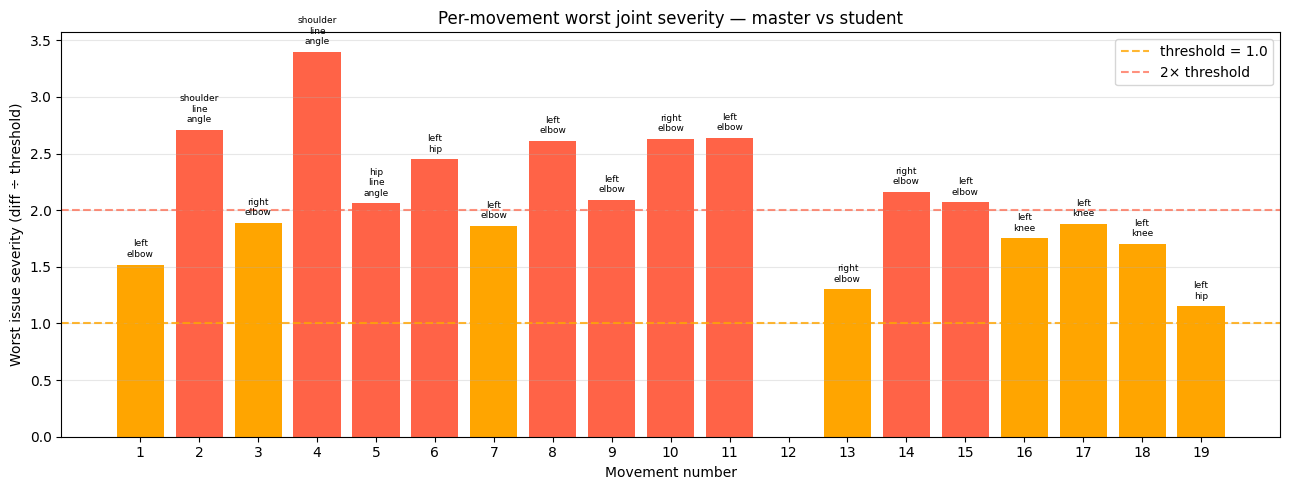

In [10]:
movs = sorted(summaries)
worst_severity = [summaries[m].issues[0].severity if summaries[m].issues else 0.0 for m in movs]
worst_joint    = [summaries[m].issues[0].joint if summaries[m].issues else "" for m in movs]

bar_colors = [
    "tomato" if s > 2.0 else ("orange" if s > 1.0 else "steelblue")
    for s in worst_severity
]

fig, ax = plt.subplots(figsize=(13, 5))
bars = ax.bar(movs, worst_severity, color=bar_colors)
ax.axhline(1.0, color="orange", linestyle="--", alpha=0.8, label="threshold = 1.0")
ax.axhline(2.0, color="tomato", linestyle="--", alpha=0.7, label="2× threshold")

for bar, sev, jnt in zip(bars, worst_severity, worst_joint):
    if sev > 0:
        label = jnt.replace("_", "\n")
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            sev + 0.05,
            label,
            ha="center", va="bottom", fontsize=6.5, color="black"
        )

ax.set_xticks(movs)
ax.set_xlabel("Movement number")
ax.set_ylabel("Worst issue severity (diff ÷ threshold)")
ax.set_title("Per-movement worst joint severity — master vs student")
ax.legend()
ax.grid(True, axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

## Step 7 — Full issue summary across all 19 movements

In [11]:
print(f"{'Mov':>4} {'mean_rms':>9} {'Joint':>25} {'Diff°':>7} {'Direction':>12} {'Severity':>9}")
print("-" * 75)
for mov_num in sorted(summaries):
    s = summaries[mov_num]
    if not s.issues:
        print(f"{mov_num:>4} {s.mean_rms:>9.1f}  {'—  (no issues)':}")
        continue
    first = True
    for issue in s.issues:
        rms_str = f"{s.mean_rms:>9.1f}" if first else " " * 9
        print(
            f"{mov_num if first else '':>4} {rms_str}"
            f"  {issue.joint:>25} {issue.diff:>7.1f} {issue.direction:>12} {issue.severity:>9.2f}"
        )
        first = False

 Mov  mean_rms                     Joint   Diff°    Direction  Severity
---------------------------------------------------------------------------
   1      14.9                 left_elbow    22.8    too_small      1.52
   2      39.9        shoulder_line_angle    67.8    too_small      2.71
                              right_elbow    31.9    too_small      2.13
                           hip_line_angle    52.0    too_large      2.08
   3      25.6                right_elbow    28.3    too_large      1.89
                               right_knee    21.7    too_large      1.44
                               left_elbow    27.0    too_small      1.35
   4      46.7        shoulder_line_angle    85.1    too_large      3.40
                           hip_line_angle    56.5    too_large      2.26
                               left_elbow    31.5    too_small      2.10
   5      34.2             hip_line_angle    51.6    too_small      2.06
                               left_elbow    27.5